# Pipeline: Circular baseada em Genes MLST
## *Streptococcus agalactiae* — Análise de Sequence Types (STs)

---

### Objetivo
Construir uma árvore filogenética circular das 159 cepas de *S. agalactiae*, usando os **7 genes housekeeping do MLST** (adhP, pheS, atr, glnA, sdhA, glcK, tkt), anotada com os Sequence Types (STs) para visualização no **iTOL**.

### Por que não usar o Roary aqui?
O **Roary** é ideal para pangenoma completo, como foi feito anteriormente. Para o MLST, o caminho correto é diferente porque os 7 genes MLST são genes do *core genome* (presentes em **todas** as cepas), então o Roary os agruparia num único cluster sem distinguir os alelos. A abordagem correta é:

```
Alelos PubMLST → BLAST nos genomas → Concatenação → MAFFT → IQ-TREE → iTOL
```

---
## ETAPA 0 — Instalar dependências

Antes de começar, garantimos que todas as bibliotecas Python e ferramentas de linha de comando necessárias estão instaladas.

**Ferramentas externas necessárias:**
- `blast+` — para buscar os genes MLST nos genomas
- `mafft` — para alinhar as sequências concatenadas
- `iqtree2` — para construir a árvore filogenética

In [ ]:
# Criar um ambiente conda para análise de filogenia de MLST
## Via Terminal:
conda create -n mlst_phylogeny -c conda-forge -c bioconda \
  python=3.11 \
  blast \
  mafft \
  iqtree=2.4.* \
  biopython \
  requests \
  pandas \
  matplotlib \
  seaborn \
  jupyterlab \
  ipykernel \
  pip -y

conda activate mlst_phylogeny

# Pacotes para poder utilizar o JupyterLab/VScode/... dentro do ambiente conda e acessar os kernels do ambiente 
conda install -c conda-forge nb_conda_kernels jupyterlab magic-wormhole notebook ipython ipykernel


---
## Configurações Gerais

Defina aqui os caminhos dos seus arquivos. **Altere conforme necessário.**

In [7]:
import os # para manipulação de arquivos e diretórios
from pathlib import Path # para manipulação de caminhos de arquivos

In [8]:
# Configuração das variáveis e pastas/diretórios do projeto
GENOME_DIR = "/mnt/dados/victor_baca/projeto_mlst/genoma"                     # pasta com os arquivos .fna
MLST_TSV   = "/mnt/dados/victor_baca/projeto_mlst/mlst_resultados.tsv"        # saída do mlst (Torsten Seemann)
OUT_DIR    = "/mnt/dados/victor_baca/projeto_mlst/mlst_phylogeny"             # pasta de saída (será criada)
# ─────────────────────────────────────────────────────────────────────────────

# Os 7 genes MLST de S. agalactiae (esquema PubMLST: sagalactiae)
GENES = ["adhP", "pheS", "atr", "glnA", "sdhA", "glcK", "tkt"]

# Subpastas do projeto
DB_DIR      = os.path.join(OUT_DIR, "mlst_db")          # alelos .fa
BLAST_DB    = os.path.join(OUT_DIR, "blast_db")          # bancos BLAST
ALLELES_DIR = os.path.join(OUT_DIR, "alleles_by_gene")   # sequências por gene
CONCAT_DIR  = os.path.join(OUT_DIR, "concatenated")      # sequências concatenadas
ALIGN_DIR   = os.path.join(OUT_DIR, "alignment")         # alinhamento MAFFT
TREE_DIR    = os.path.join(OUT_DIR, "tree")              # árvore IQ-TREE
ITOL_DIR    = os.path.join(OUT_DIR, "itol")              # arquivos de anotação
LOG_DIR     = os.path.join(OUT_DIR, "logs")              # logs de erro

# Cria todas as pastas
for d in [DB_DIR, BLAST_DB, ALLELES_DIR, CONCAT_DIR,
          ALIGN_DIR, TREE_DIR, ITOL_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Configurações carregadas")
print(f"   Genomas  : {GENOME_DIR}")
print(f"   TSV MLST : {MLST_TSV}")
print(f"   Saída    : {OUT_DIR}")

✅ Configurações carregadas
   Genomas  : /mnt/dados/victor_baca/projeto_mlst/genoma
   TSV MLST : /mnt/dados/victor_baca/projeto_mlst/mlst_resultados.tsv
   Saída    : /mnt/dados/victor_baca/projeto_mlst/mlst_phylogeny


---
## ETAPA 1 — Explorar o arquivo TSV do `mlst`

O arquivo `mlst_resultados.tsv` foi gerado pela ferramenta `mlst` (Torsten Seemann). Cada linha representa uma cepa e contém:
- **Coluna 1:** caminho do genoma
- **Coluna 2:** espécie identificada
- **Coluna 3:** ST (Sequence Type)
- **Colunas 4–10:** alelo de cada um dos 7 genes, no formato `gene(numero)`

Alguns STs aparecem como `-`, o que significa que pelo menos um alelo não foi reconhecido pelo banco de dados (pode ser um alelo novo ou uma sequência ambígua, indicada por `?` ou `~`).

In [15]:
import pandas as pd
import re

# Lê o TSV e adiciona nomes de colunas
df_raw = pd.read_csv(
    MLST_TSV,
    sep="\t",
    header=None,
    names=["genome_path", "organism", "ST"] + GENES
)

# Extrai o nome da cepa a partir do caminho do arquivo
df_raw["sample"] = df_raw["genome_path"].apply(
    lambda x: Path(x).stem.replace("_genomic", "")
)

print(f"Total de amostras: {len(df_raw)}")
print(f"Colunas: {list(df_raw.columns)}")
df_raw

Total de amostras: 159
Colunas: ['genome_path', 'organism', 'ST', 'adhP', 'pheS', 'atr', 'glnA', 'sdhA', 'glcK', 'tkt', 'sample']


,genome_path,organism,ST,adhP,pheS,atr,glnA,sdhA,glcK,tkt,sample
0,genoma/01173_genomic.fna,sagalactiae,7,adhP(10),pheS(1),atr(2),glnA(1),sdhA(3),glcK(2),tkt(2),01173
1,genoma/09mas018883_genomic.fna,sagalactiae,1,adhP(1),pheS(1),atr(2),glnA(1),sdhA(1),glcK(2),tkt(2),09mas018883
2,genoma/138spar_genomic.fna,sagalactiae,261,adhP(54),pheS(17),atr(31),glnA(4),sdhA(26),glcK(25),tkt(19),138spar
3,genoma/1B13M_genomic.fna,sagalactiae,1,adhP(1),pheS(1),atr(2),glnA(1),sdhA(1),glcK(2),tkt(2),1B13M
4,genoma/2-22_genomic.fna,sagalactiae,261,adhP(54),pheS(17),atr(31),glnA(4),sdhA(26),glcK(25),tkt(19),2-22
...,...,...,...,...,...,...,...,...,...,...,...
154,genoma/YZ1605_genomic.fna,sagalactiae,67,adhP(13),pheS(1),atr(1),glnA(13),sdhA(1),glcK(1),tkt(5),YZ1605
155,genoma/SA10-UEL.fa,sagalactiae,283,adhP(9),pheS(5),atr(7),glnA(1),sdhA(3),glcK(3),tkt(2),SA10-UEL
156,genoma/SA11-UEL.fa,sagalactiae,283,adhP(9),pheS(5),atr(7),glnA(1),sdhA(3),glcK(3),tkt(2),SA11-UEL
157,genoma/SA8-UEL.fa,sagalactiae,-,adhP(52),pheS(17),atr(31),glnA(4),sdhA(26),glcK(217?),tkt(19),SA8-UEL


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

# Conta quantas cepas por ST
st_counts = Counter(df_raw["ST"].astype(str))
st_sorted = sorted(st_counts.items(), key=lambda x: -x[1])

print("=== Distribuição de STs ===")
print(f"Total de STs únicos: {len(st_sorted)}")
print(f"Cepas com ST indefinido (-): {st_counts.get('-', 0)}")
print()

# Tabela resumida
st_df = pd.DataFrame(st_sorted, columns=["ST", "n_cepas"])
print(st_df.to_string(index=False))

=== Distribuição de STs ===
Total de STs únicos: 29
Cepas com ST indefinido (-): 37

  ST  n_cepas
   -       37
 103       17
   1       15
 283       14
   7        9
 260        9
  26        8
  23        6
  17        5
   4        5
 927        5
 261        3
  22        3
  61        3
  67        3
 591        2
   8        2
  91        2
 167        1
 130        1
  12        1
  64        1
 452        1
 928        1
 335        1
1878        1
  19        1
   2        1
1640        1


In [22]:
# Analisa a qualidade dos alelos: quantos são certos vs. ambíguos
## Certos = alelo definido, sem caracteres ambíguos
## Ambíguos = alelo definido, mas com caracteres como '?' ou '~' indicando incerteza
def classify_allele(val):
    """Retorna 'certo', 'ambiguo' ou 'ausente' para um valor de alelo."""
    val = str(val)
    m = re.match(r'[^(]+\(([^)]+)\)', val)
    if not m:
        return "ausente"
    inner = m.group(1)
    if inner == "-":
        return "ausente"
    if any(c in inner for c in ("?", "~")):
        return "ambiguo"
    return "certo"

for gene in GENES:
    counts = df_raw[gene].apply(classify_allele).value_counts()
    print(f"{gene:6s}: certo={counts.get('certo',0):3d}  "
          f"ambiguo={counts.get('ambiguo',0):3d}  "
          f"ausente={counts.get('ausente',0):3d}")

adhP  : certo=156  ambiguo=  3  ausente=  0
pheS  : certo=159  ambiguo=  0  ausente=  0
atr   : certo=154  ambiguo=  4  ausente=  1
glnA  : certo=156  ambiguo=  3  ausente=  0
sdhA  : certo=157  ambiguo=  2  ausente=  0
glcK  : certo=130  ambiguo= 29  ausente=  0
tkt   : certo=159  ambiguo=  0  ausente=  0


---
## ETAPA 2 — Baixar os alelos do PubMLST

O **PubMLST** é o banco de dados oficial do método MLST. Para cada um dos 7 genes, existe um arquivo `.fa` (formato FASTA) contendo as sequências de **todos os alelos conhecidos** daquele gene em *S. agalactiae*.

Por exemplo, o arquivo `adhP.fa` contém:
```
>adhP_1
ATGAAAGCAATTTTAGGTTTAATTGG...
>adhP_2
ATGAAAGCAATTTTAGGTTTAATTGG...
```

Usaremos esses arquivos para duas coisas:
1. Buscar diretamente a sequência pelo número do alelo (quando o ST é certo)
2. Criar bancos BLAST para extrair o gene diretamente do genoma (quando o alelo é `?` ou `-`)

In [ ]:
# https://pubmlst.org/data
%%bash
cd /mnt/dados/victor_baca/projeto_mlst/mlst_phylogeny/mlst_db

urls=(
  "https://rest.pubmlst.org/db/pubmlst_sagalactiae_seqdef/loci/adhP/alleles_fasta"
  "https://rest.pubmlst.org/db/pubmlst_sagalactiae_seqdef/loci/pheS/alleles_fasta"
  "https://rest.pubmlst.org/db/pubmlst_sagalactiae_seqdef/loci/atr/alleles_fasta"
  "https://rest.pubmlst.org/db/pubmlst_sagalactiae_seqdef/loci/glnA/alleles_fasta"
  "https://rest.pubmlst.org/db/pubmlst_sagalactiae_seqdef/loci/sdhA/alleles_fasta"
  "https://rest.pubmlst.org/db/pubmlst_sagalactiae_seqdef/loci/glcK/alleles_fasta"
  "https://rest.pubmlst.org/db/pubmlst_sagalactiae_seqdef/loci/tkt/alleles_fasta"
)

for u in "${urls[@]}"; do
  gene=$(echo "$u" | awk -F'/' '{print $(NF-1)}')     # pega o nome do locus (adhP, pheS, etc.)
  out="${gene}.fasta"
  echo "Baixando $gene -> $out"
  curl -fsSL "$u" -o "$out"
done

ls -lh *.fasta

In [20]:
# Verifica quantos alelos existem por gene no banco
## monta um dicionário gene -> caminho do arquivo fasta

import os

print("=== Número de alelos no banco PubMLST ===")
for gene in GENES:
    # monta o caminho do arquivo fasta para o gene
    path = os.path.join(DB_DIR, f"{gene}.fasta")
    # verifica se o arquivo existe
    if not os.path.exists(path):
        # se não existir, imprime uma mensagem de erro e pula para o próximo gene
        print(f"  {gene:6s}: arquivo não encontrado -> {path}")
        continue
    # conta quantas sequências existem no arquivo fasta (número de alelos)
    n = sum(1 for line in open(path) if line.startswith(">"))
    # imprime o resultado
    print(f"  {gene:6s}: {n} alelos conhecidos")


=== Número de alelos no banco PubMLST ===
  adhP  : 444 alelos conhecidos
  pheS  : 184 alelos conhecidos
  atr   : 280 alelos conhecidos
  glnA  : 229 alelos conhecidos
  sdhA  : 221 alelos conhecidos
  glcK  : 241 alelos conhecidos
  tkt   : 182 alelos conhecidos


---
## ETAPA 3 — Criar bancos de dados BLAST

Para as cepas em que o alelo é ambíguo (marcado com `?`, `~` ou `-`), não podemos simplesmente buscar pelo número no banco. Nesses casos, usamos o **BLAST** para encontrar o gene diretamente no genoma da cepa.

O `makeblastdb` transforma cada arquivo `.fa` em um banco de dados consultável pelo `blastn`.

In [21]:
import subprocess
# Função para criar um banco de dados BLAST a partir de um arquivo fasta
def create_blast_db(fa_path, db_prefix, log_dir):
    """
    Cria um banco de dados BLAST nucleotídico a partir de um arquivo .fa.
    Retorna True se bem-sucedido.
    """
    gene_name = Path(fa_path).stem # extrai o nome do gene a partir do nome do arquivo fasta
    nhr_file  = db_prefix + ".nhr"  # arquivo indicador de que o banco já existe
    # Verifica se o banco já existe (presença do arquivo .nhr)
    if os.path.exists(nhr_file):
        print(f"  ⏭  BLAST DB para {gene_name} já existe")
        return True
    # Comando para criar o banco BLAST
    cmd = [
        "makeblastdb",
        "-in",     fa_path,
        "-dbtype", "nucl",
        "-out",    db_prefix,
        "-title",  gene_name
    ]
    # Executa o comando e redireciona stdout e stderr para um arquivo de log
    log_file = os.path.join(log_dir, f"makeblastdb_{gene_name}.log")
    with open(log_file, "w") as lf:
        result = subprocess.run(cmd, stdout=lf, stderr=lf)
    # Verifica o código de retorno para determinar se o banco foi criado com sucesso
    if result.returncode == 0:
        print(f"  ✅ BLAST DB criado: {gene_name}")
        return True
    else:
        print(f"  ❌ Erro ao criar BLAST DB para {gene_name}. Veja {log_file}")
        return False

print("=== Criando bancos BLAST ===")
blast_dbs = {}
# Itera sobre os arquivos fasta dos genes e cria um banco BLAST para cada um
for gene, fa in fa_paths.items():
    prefix = os.path.join(BLAST_DB, gene)
    if create_blast_db(fa, prefix, LOG_DIR):
        blast_dbs[gene] = prefix

print(f"\n✅ {len(blast_dbs)}/{len(GENES)} bancos BLAST prontos")

=== Criando bancos BLAST ===
  ✅ BLAST DB criado: adhP
  ✅ BLAST DB criado: pheS
  ✅ BLAST DB criado: atr
  ✅ BLAST DB criado: glnA
  ✅ BLAST DB criado: sdhA
  ✅ BLAST DB criado: glcK
  ✅ BLAST DB criado: tkt

✅ 7/7 bancos BLAST prontos


---
## ETAPA 4 — Extrair a sequência de cada alelo por genoma

Para cada cepa, usamos o número do alelo reportado pelo `mlst` e buscamos a sequência exata no arquivo `.fa` do PubMLST.

**Estratégia dupla:**
- ✅ **Alelo certo** (ex: `adhP(10)`): pega a sequência `>adhP_10` diretamente do `.fa`
- ⚠️ **Alelo ambíguo** (ex: `adhP(10?)`, `adhP(-)`, `adhP(~10)`): usa BLAST para buscar o gene diretamente no genoma da cepa e retorna a melhor sequência encontrada

In [23]:
# ── Função auxiliar: extrai número do alelo ──────────────────────────────────
def parse_allele_number(allele_str, gene):
    """
    Extrai o número do alelo de uma string no formato gene(numero).
    
    Exemplos:
      adhP(10)   → 10    (certo)
      adhP(10?)  → None  (incerto)
      adhP(-)    → None  (ausente)
      adhP(~10)  → None  (aproximado)
    """
    m = re.match(rf'{re.escape(gene)}\(([^)]+)\)', str(allele_str))
    if not m:
        return None
    val = m.group(1).strip()
    if any(c in val for c in ("?", "-", "~", " ")):
        return None
    try:
        return int(val)
    except ValueError:
        return None

In [24]:
# ── Função: busca a sequência no arquivo .fa pelo número do alelo ────────────
def get_allele_sequence_from_fa(gene, allele_num, db_dir):
    """
    Abre o arquivo .fa e retorna a sequência do alelo com número allele_num.
    O header esperado é: >gene_N (ex: >adhP_10)
    """
    fa_path = os.path.join(db_dir, f"{gene}.fasta")
    if not os.path.exists(fa_path):
        return None

    target_header = f">{gene}_{allele_num}"
    seq_lines = []
    found = False

    with open(fa_path) as fh:
        for line in fh:
            line = line.rstrip()
            if line.startswith(">"):
                if found:
                    break  # próxima entrada → termina
                # Aceita '>adhP_10' ou '>adhP_10 texto extra'
                if line == target_header or line.startswith(target_header + " "):
                    found = True
                    seq_lines = []
            elif found:
                seq_lines.append(line)

    return "".join(seq_lines) if found else None

In [25]:
# ── Função: busca o gene no genoma via BLAST (fallback) ───────────────────────
def blast_gene_in_genome(gene, genome_fna, blast_db_prefix, db_dir, min_pident=80.0):
    """
    Usa blastn para encontrar o gene (usando os alelos do .fa como query)
    contra o genoma da cepa (subject).
    Retorna a sequência da melhor hit ou None.
    """
    fa_query = os.path.join(db_dir, f"{gene}.fasta")
    if not os.path.exists(fa_query) or not os.path.exists(genome_fna):
        return None

    cmd = [
        "blastn",
        "-query",           fa_query,   # alelos como query
        "-subject",         genome_fna,  # genoma como subject
        "-outfmt",          "6 qseqid sseqid pident length qstart qend sstart send sseq evalue",
        "-max_target_seqs", "1",
        "-max_hsps",        "1",
        "-perc_identity",   str(min_pident),
        "-evalue",          "1e-10",
        "-word_size",       "7",
        "-task",            "blastn"
    ]

    try:
        r = subprocess.run(cmd, capture_output=True, text=True, timeout=120)
        if r.returncode == 0 and r.stdout.strip():
            # Melhor hit: pega a sequência do alinhamento (coluna sseq)
            best = r.stdout.strip().split("\n")[0].split("\t")
            if len(best) >= 9:
                seq = best[8].replace("-", "")  # remove gaps do alinhamento
                if len(seq) > 50:
                    return seq
    except subprocess.TimeoutExpired:
        print(f"    ⏱ Timeout no BLAST para {gene}")
    except Exception as e:
        pass
    return None

In [26]:
# ── Função: localiza o genoma no filesystem ───────────────────────────────────
def find_genome_file(genome_path_from_tsv, genome_dir):
    """Tenta encontrar o arquivo .fna de um genoma em vários lugares."""
    # Caminho direto como está no TSV
    if os.path.exists(genome_path_from_tsv):
        return genome_path_from_tsv
    # Só o basename dentro do genome_dir
    basename = os.path.basename(genome_path_from_tsv)
    candidate = os.path.join(genome_dir, basename)
    if os.path.exists(candidate):
        return candidate
    # Extensões alternativas
    stem = Path(basename).stem
    for ext in [".fna", ".fa", ".fasta", ".fas"]:
        c = os.path.join(genome_dir, stem + ext)
        if os.path.exists(c):
            return c
    return None


print("✅ Funções auxiliares definidas")

✅ Funções auxiliares definidas


In [29]:
# Teste rápido: busca o alelo adhP_1 no banco
test_seq = get_allele_sequence_from_fa("adhP", 1, DB_DIR)
if test_seq:
    print(f"   Teste - adhP alelo 1: {len(test_seq)} bp → {test_seq[:30]}...")
else:
    print("   ⚠️ Teste falhou — verifique se o arquivo adhP.fasta foi baixado")

   Teste - adhP alelo 1: 501 bp → GGCATTGACTTGGATATTCATCAAGGAGAA...


In [30]:
# ── EXTRAÇÃO PRINCIPAL ────────────────────────────────────────────────────────
# Para cada cepa, extrai as sequências dos 7 genes MLST

import json
from IPython.display import display

results = []        # lista de dicts com resultados por cepa
log_missing = []    # cepas/genes com problemas

print(f"=== Extraindo sequências MLST de {len(df_raw)} cepas ===")
print("(. = alelo direto do banco  |  B = via BLAST  |  X = não encontrado)\n")

for idx, row in df_raw.iterrows():
    sample = row["sample"]
    st     = str(row["ST"])

    # Localiza o arquivo do genoma
    genome_fna = find_genome_file(row["genome_path"], GENOME_DIR)

    if genome_fna is None:
        log_missing.append({"sample": sample, "gene": "GENOMA", "motivo": "arquivo não encontrado"})
        print(f"  ❌ {sample}: genoma não encontrado")
        continue

    sample_seqs   = {}  # gene → sequência
    sample_method = {}  # gene → como foi obtida ('db' ou 'blast' ou 'N')

    for gene in GENES:
        allele_num = parse_allele_number(row[gene], gene)
        seq = None

        # ── Tentativa 1: busca pelo número no banco .fa ─────────────────────
        if allele_num is not None:
            seq = get_allele_sequence_from_fa(gene, allele_num, DB_DIR)
            if seq:
                sample_method[gene] = "db"

        # ── Tentativa 2: BLAST direto no genoma ──────────────────────────────
        if seq is None:
            seq = blast_gene_in_genome(gene, genome_fna, blast_dbs.get(gene, ""),
                                       DB_DIR)
            if seq:
                sample_method[gene] = "blast"

        # ── Fallback: Ns como placeholder ─────────────────────────────────────
        if seq is None:
            seq = "N" * 400
            sample_method[gene] = "missing"
            log_missing.append({"sample": sample, "gene": gene, "motivo": "não extraído"})

        sample_seqs[gene] = seq

        # Salva arquivo individual (um .fasta por gene por cepa)
        gene_dir = os.path.join(ALLELES_DIR, gene)
        os.makedirs(gene_dir, exist_ok=True)
        with open(os.path.join(gene_dir, f"{sample}.fasta"), "w") as f:
            f.write(f">{sample}\n{seq}\n")

    results.append({
        "sample":  sample,
        "st":      st,
        "seqs":    sample_seqs,
        "methods": sample_method
    })

    # Indicador de progresso por linha
    status = "".join(
        "." if sample_method[g] == "db" else
        "B" if sample_method[g] == "blast" else "X"
        for g in GENES
    )
    if (idx + 1) % 10 == 0:
        print(f"  [{idx+1:3d}] {sample:30s} | {status}")

print(f"\n✅ {len(results)} cepas processadas")
if log_missing:
    print(f"⚠️  {len(log_missing)} alelos não extraídos (ver log abaixo)")

=== Extraindo sequências MLST de 159 cepas ===
(. = alelo direto do banco  |  B = via BLAST  |  X = não encontrado)

  [ 10] 3B13R                          | .......
  [ 20] 874391                         | .......
  [ 30] BR-MHR519                      | .......
  [ 40] CU_GBS_98                      | .......
  [ 50] GBS114                         | ..B.B..
  [ 60] GBS184                         | .......
  [ 70] HFJ14                          | .....B.
  [ 80] NGBS128                        | .......
  [ 90] SA01                           | .....B.
  [100] SA191                          | .......
  [110] SA2BKE                         | .......
  [120] SA53                           | .......
  [130] SG-M158                        | .......
  [140] SGEHI2015-113                  | .......
  [150] TAH10_84                       | .......

✅ 159 cepas processadas


In [35]:
# Resumo Completo dos resultados por cepa (visualização rápida) 
print(f"=== Resumo retroativo de {len(results)} cepas ===")
print("(. = alelo direto do banco  |  B = via BLAST  |  X = não encontrado)\n")

for idx, r in enumerate(results, start=1):
    status = "".join(
        "." if r["methods"].get(g) == "db" else
        "B" if r["methods"].get(g) == "blast" else
        "X"
        for g in GENES
    )
    print(f"  [{idx:3d}] {r['sample']:30s} | {status} | ST={r['st']}")


=== Resumo retroativo de 159 cepas ===
(. = alelo direto do banco  |  B = via BLAST  |  X = não encontrado)

  [  1] 01173                          | ....... | ST=7
  [  2] 09mas018883                    | ....... | ST=1
  [  3] 138spar                        | ....... | ST=261
  [  4] 1B13M                          | ....... | ST=1
  [  5] 2-22                           | ....... | ST=261
  [  6] 2012-845                       | ....... | ST=17
  [  7] 32790-3A                       | ....... | ST=17
  [  8] 3966RFQB                       | ....... | ST=167
  [  9] 3B11V                          | ....... | ST=23
  [ 10] 3B13R                          | ....... | ST=23
  [ 11] 3B21M                          | ....... | ST=23
  [ 12] 4B14M                          | ....... | ST=130
  [ 13] 5B15M                          | ....... | ST=1
  [ 14] 5B20M                          | ....... | ST=1
  [ 15] 5B21V                          | ....... | ST=1
  [ 16] 5B28V                         

In [36]:
# Resumo dos métodos de extração
method_summary = {"db": 0, "blast": 0, "missing": 0}
for r in results:
    for m in r["methods"].values():
        method_summary[m] += 1

total = sum(method_summary.values())
print("=== Resumo da extração ===")
print(f"  Do banco de alelos (certo) : {method_summary['db']:4d} ({100*method_summary['db']/total:.1f}%)")
print(f"  Via BLAST no genoma        : {method_summary['blast']:4d} ({100*method_summary['blast']/total:.1f}%)")
print(f"  Não extraído (Ns)          : {method_summary['missing']:4d} ({100*method_summary['missing']/total:.1f}%)")

if log_missing:
    print("\n--- Alelos com problema ---")
    df_missing = pd.DataFrame(log_missing)
    print(df_missing.to_string(index=False))
    df_missing.to_csv(os.path.join(LOG_DIR, "missing_alleles.tsv"), sep="\t", index=False)

=== Resumo da extração ===
  Do banco de alelos (certo) : 1071 (96.2%)
  Via BLAST no genoma        :   42 (3.8%)
  Não extraído (Ns)          :    0 (0.0%)


---
## ETAPA 5 — Concatenar os 7 genes por cepa

Agora que temos a sequência de cada um dos 7 genes para cada cepa, precisamos **concatená-los em ordem** para criar uma sequência única por cepa.

A ordem de concatenação é sempre a mesma para todas as cepas:
```
adhP + pheS + atr + glnA + sdhA + glcK + tkt
```

Isso garante que, ao alinhar, cada posição do alinhamento corresponda ao mesmo gene em todas as cepas.

In [37]:
concat_fasta = os.path.join(CONCAT_DIR, "mlst_concatenated.fasta")

with open(concat_fasta, "w") as f:
    for r in results:
        # Concatena na ordem fixa dos 7 genes
        concat_seq = "".join(r["seqs"][gene] for gene in GENES)
        f.write(f">{r['sample']}\n{concat_seq}\n")

# Verifica o arquivo
n_seqs   = sum(1 for line in open(concat_fasta) if line.startswith(">"))
len_seqs = [len(r["seqs"][GENES[0]]) + len(r["seqs"][GENES[-1]]) for r in results[:3]]

print(f"✅ Arquivo FASTA concatenado criado: {concat_fasta}")
print(f"   Número de sequências : {n_seqs}")

# Calcula comprimento médio
lens = []
for r in results:
    l = sum(len(r["seqs"][g]) for g in GENES)
    lens.append(l)

print(f"   Comprimento total (concat): {min(lens)} – {max(lens)} bp")
print(f"   Comprimento médio         : {int(sum(lens)/len(lens))} bp")
print("")
print("Prévia das primeiras 3 sequências:")
with open(concat_fasta) as f:
    for i, line in enumerate(f):
        if i < 6:
            print(f"  {line.rstrip()[:80]}" + ("..." if len(line) > 80 else ""))

✅ Arquivo FASTA concatenado criado: /mnt/dados/victor_baca/projeto_mlst/mlst_phylogeny/concatenated/mlst_concatenated.fasta
   Número de sequências : 159
   Comprimento total (concat): 3008 – 3456 bp
   Comprimento médio         : 3432 bp

Prévia das primeiras 3 sequências:
  >01173
  CCAGGACGCATTTTGGGTCACGAAGGCATTGGTATAGTAGAAGAAATTGGAGAAGGCGTAACGTCTTTGAGGGTTGGTGA...
  >09mas018883
  CCAGGACGCATTTTGGGTCACGAAGGCATTGGTATAGTAGAAGAAATTGGAGAAGGCGTAACGTCTTTGAGGGTTGGTGA...
  >138spar
  CCAGGACGCATTTTGGGTCACGAAGGCATTGGTATAGTAGAAGAAATTGGAGAAGGCGTAACGTCTTTGAGGGTTGGTGA...


---
## ETAPA 6 — Alinhar com MAFFT

O **MAFFT** é uma ferramenta de alinhamento múltiplo de sequências. Ele ajusta as sequências para que posições homólogas (equivalentes evolutivamente) fiquem na mesma coluna.

Para 159 sequências de genes MLST concatenados, usamos o modo `--auto`, que escolhe automaticamente o algoritmo mais adequado ao tamanho e número de sequências.

> **Nota:** Genes MLST são altamente conservados, então o alinhamento tende a ser rápido e com poucos gaps.

In [38]:
aligned_fasta = os.path.join(ALIGN_DIR, "mlst_aligned.fasta")
mafft_log     = os.path.join(LOG_DIR, "mafft.log")

print("=== Rodando MAFFT ===")
print(f"  Input  : {concat_fasta}")
print(f"  Output : {aligned_fasta}")

cmd_mafft = [
    "mafft",
    "--reorder",              # reordena sequências no output
    "--auto",                 # escolhe algoritmo automaticamente
    concat_fasta
]

with open(aligned_fasta, "w") as out_f, open(mafft_log, "w") as log_f:
    result = subprocess.run(cmd_mafft, stdout=out_f, stderr=log_f)

if result.returncode == 0:
    n_aln = sum(1 for l in open(aligned_fasta) if l.startswith(">"))
    # Comprimento do alinhamento (primeira sequência)
    seq_aln = ""
    for line in open(aligned_fasta):
        if line.startswith(">") and seq_aln:
            break
        elif not line.startswith(">"):
            seq_aln += line.strip()
    print(f"✅ Alinhamento concluído!")
    print(f"   Sequências alinhadas : {n_aln}")
    print(f"   Comprimento do alinhamento: {len(seq_aln)} bp (inclui gaps)")
else:
    print(f"❌ Erro no MAFFT. Verifique {mafft_log}")
    with open(mafft_log) as f:
        print(f.read()[-500:])

=== Rodando MAFFT ===
  Input  : /mnt/dados/victor_baca/projeto_mlst/mlst_phylogeny/concatenated/mlst_concatenated.fasta
  Output : /mnt/dados/victor_baca/projeto_mlst/mlst_phylogeny/alignment/mlst_aligned.fasta
✅ Alinhamento concluído!
   Sequências alinhadas : 159
   Comprimento do alinhamento: 3456 bp (inclui gaps)


In [39]:
# Visualiza estatísticas do alinhamento
from Bio import AlignIO

aln = AlignIO.read(aligned_fasta, "fasta")

print(f"=== Estatísticas do alinhamento ===")
print(f"  Número de sequências  : {len(aln)}")
print(f"  Comprimento do aln    : {aln.get_alignment_length()} colunas")

# Conta colunas com gaps
n_gap_cols = sum(
    1 for col in range(aln.get_alignment_length())
    if "-" in aln[:, col]
)
print(f"  Colunas com gaps      : {n_gap_cols} ({100*n_gap_cols/aln.get_alignment_length():.1f}%)")
print(f"  Colunas sem gaps      : {aln.get_alignment_length() - n_gap_cols}")

# Primeiros 5 nomes
print(f"\n  Primeiras 5 sequências:")
for rec in aln[:5]:
    print(f"    {rec.id:35s} {len(rec.seq)} bp")

=== Estatísticas do alinhamento ===
  Número de sequências  : 159
  Comprimento do aln    : 3456 colunas
  Colunas com gaps      : 722 (20.9%)
  Colunas sem gaps      : 2734

  Primeiras 5 sequências:
    01173                               3456 bp
    A909_Cas9_AEKO                      3456 bp
    A909_Cas9_AEKOrevertant             3456 bp
    A909_dCas9                          3456 bp
    A909_sCas9                          3456 bp


---
## ETAPA 7 — Construir a árvore filogenética com IQ-TREE 2

O **IQ-TREE 2** reconstrói a árvore filogenética por **máxima verossimilhança**, o mesmo método usado na dissertação.

**Parâmetros usados (mesmos da dissertação):**
| Parâmetro | O que faz |
|-----------|----------|
| `-m GTR+G` | Modelo evolutivo GTR (General Time Reversible) com variação de taxas (distribuição Gama) |
| `-B 1000` | Bootstrap ultrafast com 1000 réplicas para calcular suporte dos ramos |

> **Tempo esperado:** ~5–15 minutos para 159 sequências de MLST (~3.500 bp)

In [40]:
import time

tree_prefix = os.path.join(TREE_DIR, "mlst_tree")
tree_file   = tree_prefix + ".treefile"
iqtree_log  = os.path.join(LOG_DIR, "iqtree.log")

# Remove arquivos anteriores para não gerar conflito
for ext in [".treefile", ".iqtree", ".log", ".mldist", ".bionj", ".ckp.gz"]:
    f = tree_prefix + ext
    if os.path.exists(f):
        os.remove(f)

print("=== Rodando IQ-TREE 2 ===")
print(f"  Input  : {aligned_fasta}")
print(f"  Output : {tree_file}")
print(f"  Modelo : GTR+G")
print(f"  Bootstrap: 1000 réplicas")

cmd_iqtree = [
    "iqtree2",
    "-s",        aligned_fasta,
    "--prefix",  tree_prefix,
    "-m",        "GTR+G",
    "-B",        "1000",       # bootstrap ultrafast
    "--redo"                   # força re-execução se já existe
]

start = time.time()
with open(iqtree_log, "w") as log_f:
    result = subprocess.run(cmd_iqtree, stdout=log_f, stderr=log_f)
elapsed = time.time() - start

if result.returncode == 0 and os.path.exists(tree_file):
    print(f"✅ Árvore gerada com sucesso em {elapsed:.0f} segundos!")
    print(f"   Arquivo: {tree_file}")
else:
    print(f"❌ Erro no IQ-TREE. Verifique {iqtree_log}")
    with open(iqtree_log) as f:
        lines = f.readlines()
        print("".join(lines[-30:]))

=== Rodando IQ-TREE 2 ===
  Input  : /mnt/dados/victor_baca/projeto_mlst/mlst_phylogeny/alignment/mlst_aligned.fasta
  Output : /mnt/dados/victor_baca/projeto_mlst/mlst_phylogeny/tree/mlst_tree.treefile
  Modelo : GTR+G
  Bootstrap: 1000 réplicas
✅ Árvore gerada com sucesso em 11 segundos!
   Arquivo: /mnt/dados/victor_baca/projeto_mlst/mlst_phylogeny/tree/mlst_tree.treefile


In [41]:
# Extrai informações do relatório do IQ-TREE
iqtree_report = tree_prefix + ".iqtree"
if os.path.exists(iqtree_report):
    keywords = ["Best-fit model", "Log-likelihood", "Number of free", "Total tree length"]
    print("=== Resumo do IQ-TREE ===")
    with open(iqtree_report) as f:
        for line in f:
            for kw in keywords:
                if kw in line:
                    print(f"  {line.rstrip()}")
else:
    print("Relatório IQ-TREE não encontrado")

=== Resumo do IQ-TREE ===
  Log-likelihood of the tree: -5785.4172 (s.e. 118.6784)
  Number of free parameters (#branches + #model parameters): 124
  Total tree length (sum of branch lengths): 0.0449
  Log-likelihood of consensus tree: -5785.752533


---
## ETAPA 8 — Gerar arquivos de anotação para o iTOL

O **iTOL** (Interactive Tree Of Life) permite visualizar a árvore com camadas de informação sobrepostas. Para isso, ele usa arquivos de texto com formato específico que são carregados após a árvore.

Vamos gerar 5 arquivos de anotação, cada um com um tipo de informação diferente:

| Arquivo | O que faz no iTOL |
|---------|-------------------|
| `01_ST_label_colors.txt` | Colore o texto dos nomes das cepas por ST |
| `02_ST_leaf_labels.txt`  | Renomeia as folhas para `cepa \| ST123` |
| `03_ST_colorstrip.txt`   | Faixa colorida ao redor da árvore (principal) |
| `04_ST_text.txt`         | Exibe o número do ST ao lado de cada cepa |
| `05_allele_confidence.txt` | Indicador binário de confiança por alelo |

In [12]:
# ── Garante que 'results' existe ─────────────────────────────────────────────
# Se você está rodando esta célula isoladamente (sem ter rodado as etapas
# anteriores do notebook), este bloco reconstrói 'results' a partir do TSV.

import os
from pathlib import Path

# Ajuste estes caminhos se necessário
MLST_TSV = "/mnt/dados/victor_baca/projeto_mlst/mlst_resultados.tsv"   # mesmo valor definido na célula de config
ITOL_DIR = "/mnt/dados/victor_baca/projeto_mlst/mlst_phylogeny/itol"
OUT_DIR  = "/mnt/dados/victor_baca/projeto_mlst/mlst_phylogeny"

os.makedirs(ITOL_DIR, exist_ok=True)
os.makedirs(OUT_DIR,  exist_ok=True)

try:
    # Testa se já existe (células anteriores já rodaram)
    _ = results
    print(f"✅ 'results' já definido ({len(results)} amostras)")

except NameError:
    # Reconstrói a partir do TSV
    print("⚠️  'results' não encontrado — reconstruindo do TSV...")
    results = []
    GENES = ["adhP", "pheS", "atr", "glnA", "sdhA", "glcK", "tkt"]

    with open(MLST_TSV) as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 9:
                continue
            sample = Path(parts[0]).stem.replace("_genomic", "")
            st     = parts[2]
            alleles = {g: parts[3 + i] for i, g in enumerate(GENES)
                       if 3 + i < len(parts)}
            results.append({"sample": sample, "st": st, "alleles": alleles})

    print(f"✅ 'results' reconstruído: {len(results)} amostras")
    print(f"   Exemplo: {results[0]}")

✅ 'results' já definido (159 amostras)


In [1]:
# Copiando arquivo de anotação dos TEs feito anteriormente para a pasta do itol
%%bash
cp /mnt/dados/victor_baca/outputs/tsv/tsv/itol_is_binary.txt /mnt/dados/victor_baca/projeto_mlst/mlst_phylogeny/itol

  PALETA DE CORES - ST por Sorotipo

  Sorotipo Ib     (azul)
    ST260     #0D47A1  (n=9)
    ST927     #1976D2  (n=5)
    ST261     #42A5F5  (n=3)

  Sorotipo III    (verde)
    ST283     #1B5E20  (n=14)
    ST23      #2E7D32  (n=6)
    ST17      #388E3C  (n=5)
    ST12      #43A047  (n=1)
    ST928     #66BB6A  (n=1)
    ST19      #A5D6A7  (n=1)

  Sorotipo Ia     (laranja)
    ST7       #E64A19  (n=9)

  Sorotipo II     (vermelho)
    ST335     #B71C1C  (n=1)

  Sorotipo IV     (roxo)
    ST452     #4A148C  (n=1)

  Sorotipo V      (cinza)
    ST26      #37474F  (n=8)
    ST2       #607D8B  (n=1)

  Ia + III        (oliva)   <- multiplo
    ST103     #827717  (n=17)

  II + V          (marrom)  <- multiplo
    ST22      #6D4C41  (n=3)

  V + VI          (teal)    <- multiplo
    ST1       #00695C  (n=15)

  ST novo / raro  (rosa)
    ST4       #F06292  (n=5)
    ST61      #F48FB1  (n=3)
    ST67      #F8BBD9  (n=3)
    ST591     #FCE4EC  (n=2)
    ST8       #E91E63  (n=2)
    ST91 

/tmp/ipykernel_2627824/3205853242.py:201: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patches = [mpatches.Patch(color=c, label=l,


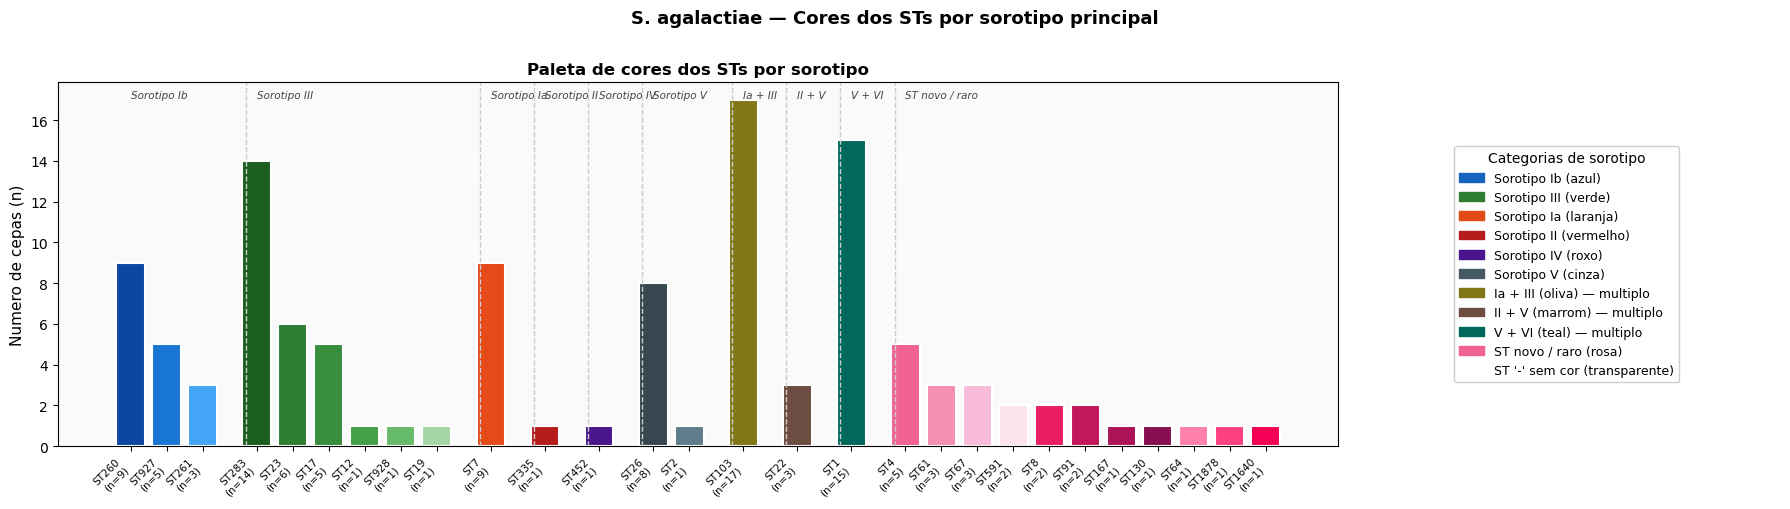

Grafico salvo: /mnt/dados/victor_baca/projeto_mlst/mlst_phylogeny/paleta_ST_sorotipo.png
Tabela salva: /mnt/dados/victor_baca/projeto_mlst/mlst_phylogeny/itol/00_color_reference.tsv


In [13]:
# Este script vai gerar um arquivo .tsv
## Esse arquivo serve como consulta para o iTOL, onde cada linha é uma amostra e as colunas são atributos (ST, sorotipo, etc.)
## Ele não serve para ser carregado no iTOL, mas sim para organizar os dados e gerar as colunas de anotação.
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── MAPEAMENTO ST → Sorotipo principal ───────────────────────────────────────

ST_SEROTYPE = {
    # Sorotipo Ib — aquatico / peixes
    '260':'Ib', '261':'Ib', '927':'Ib',

    # Sorotipo III — zoonotico
    '12' :'III','17' :'III', '19' :'III','283':'III', '23' :'III', '928':'III', 

    # Sorotipo Ia
    '7'  :'Ia',

    # Sorotipo II 
    '335':'II',

    # Sorotipo IV 
    '452':'IV',

    # Sorotipo V — humano
    '2'  :'V',  '26' :'V', 

    # STs que pertenecem a sorotipos múltiplos
    '103':'Ia-III', '22' :'II-V', '1'  :'V-VI', 

    # Novos / Raros — sem associacao consolidada
    '4'  :'novo', '8'  :'novo', '61' :'novo','67':'novo', '1640':'novo', '1878':'novo', '64' :'novo', '130':'novo', '167':'novo', '91' :'novo', '67' :'novo', '591':'novo',
}

# ── TONALIDADES por sorotipo ──────────────────────────────────────────────────
# Mais escuro = ST mais frequente | Mais claro = menos frequente
# Mesmas familias de cores da dissertacao + IV (roxo)

SEROTYPE_SHADES = {
    # Ib — AZUL (sorotipo aquatico)
    'Ib'   :['#0D47A1',   # ST260  n=9   azul profundo
             '#1976D2',   # ST261  n=3   azul medio
             '#42A5F5'],  # ST927  n=5   azul claro

    # III — VERDE (sorotipo zoonotico / neonatal)
    'III'  :['#1B5E20',   # ST283  n=14  verde profundo  (clone Singapura)
             '#2E7D32',   # ST17   n=5   verde escuro    (CC17 hipervirulento)
             '#388E3C',   # ST23   n=6   verde medio
             '#43A047',   # ST12   n=1   verde
             '#66BB6A',   # ST19   n=1   verde claro
             '#A5D6A7'],  # ST928  n=1   verde palido

    # Ia — LARANJA/MARROM (sorotipo bovino / humano)
    'Ia'   :['#E64A19'],  # ST7    n=9   laranja

    # II — VERMELHO
    'II'   :['#B71C1C'],  # ST335  n=1   vermelho escuro

    # IV — ROXO/VINHO
    'IV'   :['#4A148C'],  # ST452  n=1   roxo profundo

    # V — CINZA/ARDOSIA (sorotipo bovino)
    'V'    :['#37474F',   # ST7    n=9   cinza chumbo
             '#607D8B'],  # ST26   n=8   cinza azulado

    # ── Sorotipos multiplos: cor INTERMEDIARIA entre as duas familias ──────────
    # Ia-III: meio do caminho entre laranja (#E64A19) e verde (#2E7D32)
    #         → oliva/amarelo-esverdeado
    'Ia-III':['#827717'],  # ST103  n=17  oliva escuro

    # II-V: meio do caminho entre vermelho (#B71C1C) e cinza (#455A64)
    #       → marrom acinzentado
    'II-V'  :['#6D4C41'],  # ST22   n=3   marrom rosado

    # V-VI: V=cinza; VI e raro no GBS. Usa azul-petróleo para distinguir
    #       de Ib (azul puro) e V (cinza)
    'V-VI'  :['#00695C'],  # ST1    n=15  verde-teal escuro

    # novo — ROSA NEUTRO (STs sem sorotipo consolidado)
    'novo'  :['#F06292',   # mais frequentes
              '#F48FB1',
              '#F8BBD9',
              '#FCE4EC',
              '#E91E63',
              '#C2185B',
              '#AD1457',
              '#880E4F',
              '#FF80AB',
              '#FF4081',
              '#F50057',
              '#C51162'],
}

# ── Atribuicao: frequencia decrescente → tonalidade mais escura ───────────────
st_freq = Counter(r['st'] for r in results)
all_sts_sorted = [st for st, _ in st_freq.most_common()]

# Agrupa por categoria de sorotipo (mantendo ordem de frequencia)
serotype_groups = {s: [] for s in SEROTYPE_SHADES}
for st in all_sts_sorted:
    cat = ST_SEROTYPE.get(st)
    if cat in serotype_groups:
        serotype_groups[cat].append(st)

# Mapeia cor
st_color = {}
for cat, st_list in serotype_groups.items():
    shades = SEROTYPE_SHADES[cat]
    for i, st in enumerate(st_list):
        st_color[st] = shades[i % len(shades)]

# ST indefinido: branco → OMITIDO do DATA (= transparente no iTOL)
st_color['-'] = '#FFFFFF'

# STs nao mapeados: cinza neutro como fallback
for st in all_sts_sorted:
    if st not in st_color and st != '-':
        st_color[st] = '#CFD8DC'

# ── Print resumo ──────────────────────────────────────────────────────────────
# Ordem de exibicao: sorotipos simples primeiro, multiplos depois, novo por ultimo
DISPLAY_ORDER = ['Ib','III','Ia','II','IV','V','Ia-III','II-V','V-VI','novo']

slabel = {
    'Ib'    : 'Sorotipo Ib     (azul)',
    'III'   : 'Sorotipo III    (verde)',
    'Ia'    : 'Sorotipo Ia     (laranja)',
    'II'    : 'Sorotipo II     (vermelho)',
    'IV'    : 'Sorotipo IV     (roxo)',
    'V'     : 'Sorotipo V      (cinza)',
    'Ia-III': 'Ia + III        (oliva)   <- multiplo',
    'II-V'  : 'II + V          (marrom)  <- multiplo',
    'V-VI'  : 'V + VI          (teal)    <- multiplo',
    'novo'  : 'ST novo / raro  (rosa)',
}

print('=' * 58)
print('  PALETA DE CORES - ST por Sorotipo')
print('=' * 58)
for cat in DISPLAY_ORDER:
    sts = serotype_groups.get(cat, [])
    if not sts:
        continue
    print(f'\n  {slabel[cat]}')
    for st in sts:
        print(f'    ST{st:<6s}  {st_color[st]}  (n={st_freq[st]})')
print(f"\n  ST '-' : sem cor no iTOL  (n={st_freq.get('-', 0)})")

# ── Grafico da paleta ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5),
                          gridspec_kw={'width_ratios': [3, 1]})
ax  = axes[0]
ax2 = axes[1]

x, xticks, xlabels, sep_pos = 0, [], [], []

# Agrupa no grafico: sorotipos simples + multiplos juntos, novo separado
PLOT_ORDER = ['Ib','III','Ia','II','IV','V','Ia-III','II-V','V-VI','novo']

for cat in PLOT_ORDER:
    sts = serotype_groups.get(cat, [])
    if not sts:
        continue
    sep_pos.append((x, cat))
    for st in sts:
        ax.bar(x, st_freq[st], color=st_color[st],
               edgecolor='white', linewidth=1.5, width=0.8)
        xticks.append(x)
        xlabels.append(f'ST{st}\n(n={st_freq[st]})')
        x += 1
    x += 0.5

ylim = ax.get_ylim()[1]
for pos, cat in sep_pos:
    if pos > 0:
        ax.axvline(x=pos - 0.3, color='#CCCCCC', linewidth=1, linestyle='--')
    short = slabel[cat].split('(')[0].strip()
    ax.text(pos, ylim * 0.98, short,
            fontsize=7.5, color='#444444', va='top', style='italic')

ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, fontsize=7.5, rotation=45, ha='right')
ax.set_ylabel('Numero de cepas (n)', fontsize=11)
ax.set_title('Paleta de cores dos STs por sorotipo',
             fontsize=12, fontweight='bold')
ax.set_facecolor('#FAFAFA')

# Legenda no painel direito
ax2.axis('off')
legend_entries = [
    ('#1565C0', 'Sorotipo Ib (azul)'),
    ('#2E7D32', 'Sorotipo III (verde)'),
    ('#E64A19', 'Sorotipo Ia (laranja)'),
    ('#B71C1C', 'Sorotipo II (vermelho)'),
    ('#4A148C', 'Sorotipo IV (roxo)'),
    ('#455A64', 'Sorotipo V (cinza)'),
    ('#827717', 'Ia + III (oliva) — multiplo'),
    ('#6D4C41', 'II + V (marrom) — multiplo'),
    ('#00695C', 'V + VI (teal) — multiplo'),
    ('#F06292', 'ST novo / raro (rosa)'),
    ('#FFFFFF', "ST '-' sem cor (transparente)"),
]
patches = [mpatches.Patch(color=c, label=l,
           edgecolor='#AAAAAA' if c == '#FFFFFF' else 'none')
           for c, l in legend_entries]
ax2.legend(handles=patches, loc='center', fontsize=9,
           title='Categorias de sorotipo', title_fontsize=10,
           frameon=True, framealpha=0.95)

plt.suptitle('S. agalactiae — Cores dos STs por sorotipo principal',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'paleta_ST_sorotipo.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Grafico salvo:', os.path.join(OUT_DIR, 'paleta_ST_sorotipo.png'))

# Tabela de referencia
color_ref = os.path.join(ITOL_DIR, '00_color_reference.tsv')
with open(color_ref, 'w') as f:
    f.write('ST\tcategoria_sorotipo\tcor_hex\tn_cepas\n')
    for st in all_sts_sorted:
        cat = ST_SEROTYPE.get(st, '-' if st == '-' else 'nao_mapeado')
        f.write(f'ST{st}\t{cat}\t{st_color.get(st,"#CCCCCC")}\t{st_freq[st]}\n')
print('Tabela salva:', color_ref)

In [14]:
# Labels: ST com sorotipo multiplo mostra as duas categorias
# Ex: ST103 → 'SA01 | ST103 (Ia+III)'
# ST '-'   → 'SA01'  (sem alteracao)

out2 = os.path.join(ITOL_DIR, '02_ST_leaf_labels.txt')

def format_serotype_label(cat):
    """Formata 'Ia-III' -> 'Ia+III' para ficar mais legivel no iTOL."""
    return cat.replace('-', '+') if cat else ''

with open(out2, 'w') as f:
    f.write('LABELS\n')
    f.write('SEPARATOR TAB\n')
    f.write('DATA\n')
    for r in results:
        st  = r['st']
        cat = ST_SEROTYPE.get(st, '')
        if st == '-':
            label = r['sample']
        elif cat:
            label = f"{r['sample']} | ST{st} ({format_serotype_label(cat)})"
        else:
            label = f"{r['sample']} | ST{st}"
        f.write(f"{r['sample']}\t{label}\n")

print(f'Arquivo 2 criado: {out2}')
print('Exemplos:')
for r in results[:12]:
    st  = r['st']
    cat = ST_SEROTYPE.get(st, '')
    if st == '-':
        label = r['sample']
    elif cat:
        label = f"{r['sample']} | ST{st} ({format_serotype_label(cat)})"
    else:
        label = f"{r['sample']} | ST{st}"
    print(f"  {r['sample']:30s} -> {label}")

Arquivo 2 criado: /mnt/dados/victor_baca/projeto_mlst/mlst_phylogeny/itol/02_ST_leaf_labels.txt
Exemplos:
  01173                          -> 01173 | ST7 (Ia)
  09mas018883                    -> 09mas018883 | ST1 (V+VI)
  138spar                        -> 138spar | ST261 (Ib)
  1B13M                          -> 1B13M | ST1 (V+VI)
  2-22                           -> 2-22 | ST261 (Ib)
  2012-845                       -> 2012-845 | ST17 (III)
  32790-3A                       -> 32790-3A | ST17 (III)
  3966RFQB                       -> 3966RFQB | ST167 (novo)
  3B11V                          -> 3B11V | ST23 (III)
  3B13R                          -> 3B13R | ST23 (III)
  3B21M                          -> 3B21M | ST23 (III)
  4B14M                          -> 4B14M | ST130 (novo)


---
## RESUMO FINAL — Como carregar no iTOL

Agora que o pipeline terminou, siga estes passos para criar o gráfico circular final:

### Passo 1: Carregar a árvore
1. Acesse **https://itol.embl.de**
2. Clique em **Upload** (canto superior direito)
3. Selecione o arquivo: `mlst_phylogeny/tree/mlst_tree.treefile`

### Passo 2: Ativar modo circular
1. No painel lateral, vá em **Basic** → **Display mode** → selecione **Circular**

### Passo 3: Adicionar as anotações
Arraste e solte os arquivos da pasta `mlst_phylogeny/itol/` na janela do iTOL: